### Looking at Helium curvature on my device ###

In [1]:
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [14]:
from zeroheliumkit import Structure, Rectangle, Square, Ring, Circle, GeomCollection
from zeroheliumkit.src.settings import GRAY, BLUE, YELLOW2, BLACK
from zeroheliumkit.src.plotting import ColorHandler
from zeroheliumkit.src.importing import *

In [3]:
save_dir = "dump"

### Creating geometry

TransferDevice_simpler.gds // Layers in cell 'TOP': {np.int64(1), np.int64(2), np.int64(3), np.int64(14)}


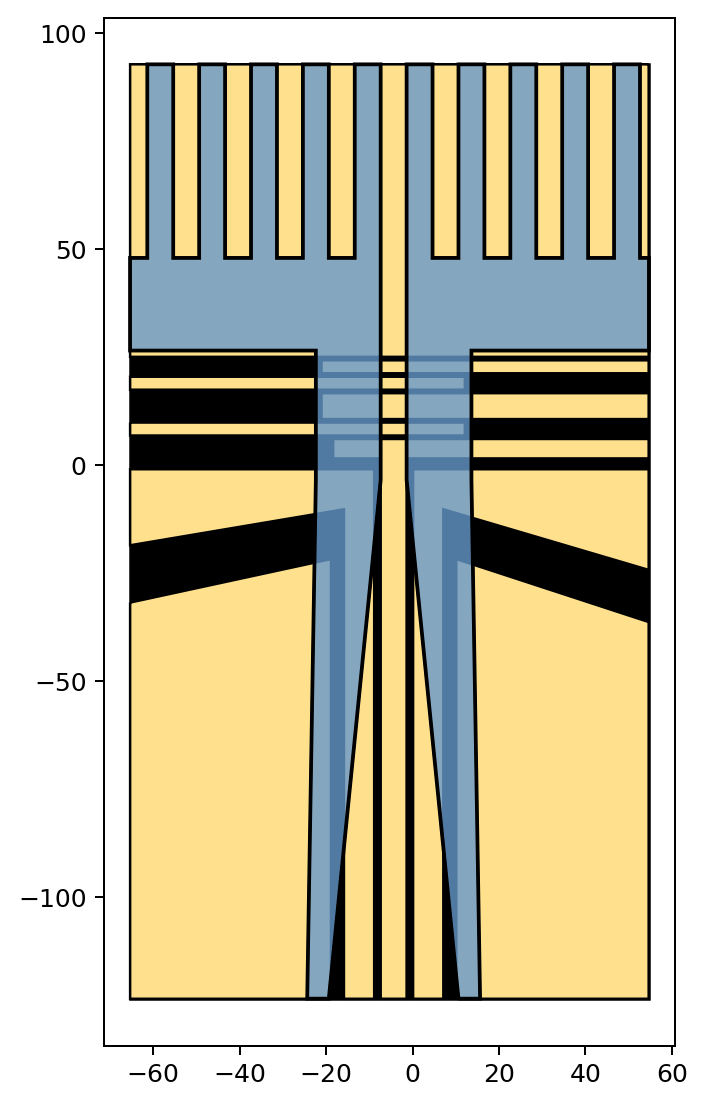

In [75]:
# Read File
file = Reader_GDS('TransferDevice_simpler.gds')
file.import2zhk("TOP")
device = GeomCollection(file.geometries)
# Rename Layers
device.rename_layer('L1','bottom')
device.rename_layer('L2','top')
device.rename_layer('L3','wafer')
device.rename_layer('L14','helium')
device.layers

#Show Device
plot_config = {'wafer':BLACK,'bottom':YELLOW2,'top':(BLUE,0.8)}
device.quickplot(plot_config)
plt.show()


## Viewing Electrodes ##

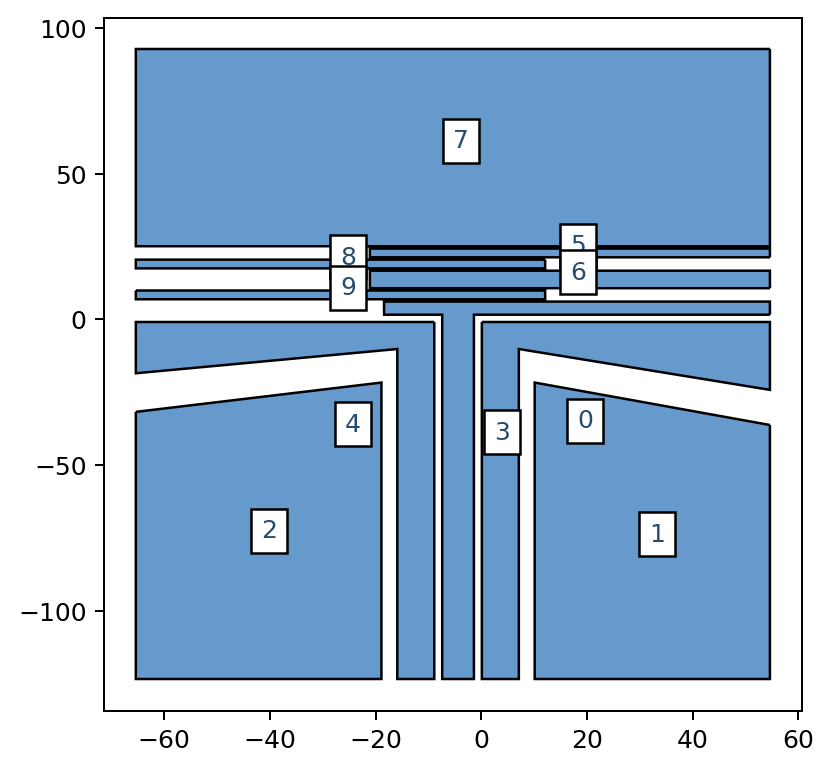

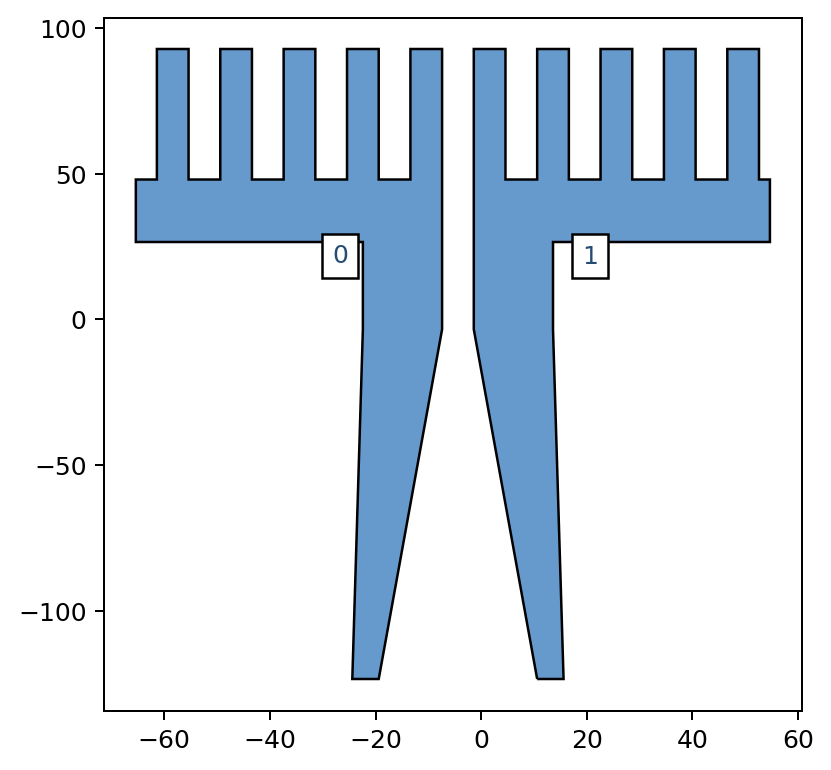

In [76]:
for layer in ["bottom","top"]:
    fig = plt.figure(1, figsize=(5,5), dpi=90)
    ax = fig.add_subplot(111)
    device.plot(ax=ax, layer=[layer],color=[BLUE],show_idx=True)
    plt.show()

### **Creating Mesh**

In [49]:
from zeroheliumkit.fem import GMSHmaker, ExtrudeSettings, MeshSettings, PECSettings, BoxFieldMeshSettings

In [67]:
# extrude parameters
d_wafer     = 10
d_metal1    = 0.025
d_metal2    = 0.025
d_diel      = 0.705
d_vac       = 25
d_He        = d_diel + d_metal2

In [81]:
Volumes = {
    'wafer':        ExtrudeSettings(device.wafer     , -d_wafer, d_wafer, 'DIELECTRIC'),
    'bottom':       ExtrudeSettings(device.bottom    , 0, d_metal1, 'METAL'),
    'dielectric':   ExtrudeSettings(device.top       , d_metal1, d_diel, 'DIELECTRIC'),
    'top':          ExtrudeSettings(device.top       , d_metal1+d_diel, d_metal2, 'METAL'),
    'helium':       ExtrudeSettings(device.wafer     , 0, d_He, 'HELIUM', ('dielectric','top')),
    'vacuum':       ExtrudeSettings(device.wafer     , d_metal1+d_He, d_vac, 'VACUUM', ('dielectric', 'top'))
}

PECs = {
    'Block':        PECSettings(device.bottom ,   [1,2], volume=Volumes['bottom']),
    'Barrier':      PECSettings(device.bottom ,   [0,4], volume=Volumes['bottom']),
    'ThinFilm':     PECSettings(device.bottom ,   [3],   volume=Volumes['bottom']),
    'Sense':        PECSettings(device.bottom ,   [6],   volume=Volumes['bottom']),
    'Door1':        PECSettings(device.bottom ,   [9],   volume=Volumes['bottom']),
    'Reservoir':    PECSettings(device.bottom ,   [7],   volume=Volumes['bottom']),
    'Twiddle':      PECSettings(device.bottom ,   [8],   volume=Volumes['bottom']),
    'Door2':        PECSettings(device.bottom ,   [5],   volume=Volumes['bottom']),
    'Top':          PECSettings(device.top ,      [0,1], volume=Volumes['top']),
}

scale = 4
mediumregion_box = [-65, 65, -110, 100, -6, 6] # [XMin, XMax, YMin, YMax, ZMin, ZMax]
fineregion_box = [-20, 20, -110, 100, -4.5, 4.5]

mesh = MeshSettings(
    dim = 3,
    fields = {
        "Box": [BoxFieldMeshSettings(Thickness=4, VIn=scale * 0.4, VOut=scale * 1, box=mediumregion_box),
                BoxFieldMeshSettings(Thickness=2, VIn=scale * 0.2, VOut=scale * 1, box=fineregion_box)]
    }
)

In [82]:
meshMKR = GMSHmaker(
    extrude = Volumes,
    surfaces = None,
    pecs = PECs,
    mesh = mesh,
    save = {"dir": save_dir, "filename": "dot"},
    open_gmsh = True,
    debug_mode = False
)

on 0: mesh is constructed                                                       
on 0: mesh saved                                                                
Gmsh generation  |███| 1/1 [100%] in 49.4s (0.02/s)                             


Below is an example of created geometry and a mesh using GMSH.

<img src="../_static/fig1.png" width="800"/>

In [79]:
meshMKR.print_physical()

Volume        ID
----------  ----
VACUUM         1
DIELECTRIC     2
METAL          3
HELIUM         4

 #-----------------------------------

Surface      ID
---------  ----
Block         5
Barrier       6
ThinFilm      7
Sense         8
Door1         9
Reservoir    10
Twiddle      11
Door2        12
Top          13


### **Helium Surface Displacement calculations**

<Axes: >

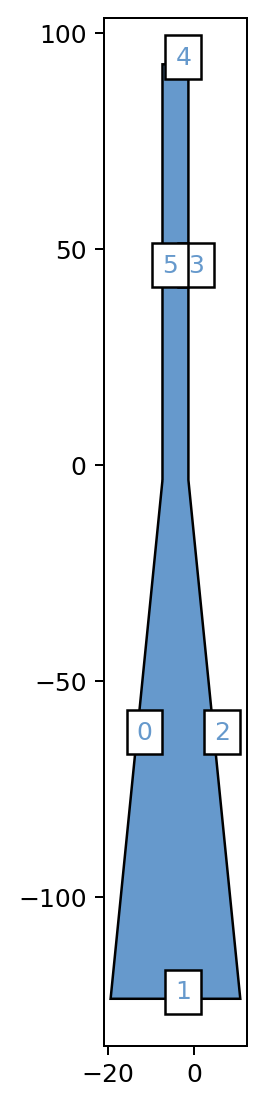

In [83]:
s = Structure()
s.add_layer('helium', device.helium)
s.quickplot(show_line_idx=True)

# We want to make boundary with line id 1 and 11 to be open boundary (Neumann boundary),
# at all other boundaries displacement is set to 0 (Dirichlet boundary)

In [55]:
from zeroheliumkit.fem.heliumsurface import GMSHmaker2D, HeliumSurfaceFreeFEM

In [84]:
gmshmkr = GMSHmaker2D(layout = s,
                      electode_config = {"type": "polygon",
                                         "bound": {"layer": ("helium", (0,)), "exclude": [-100,110], "value": 0}},
                      mesh_config = [{"Thickness": 5, "VIn": 0.9, "VOut": 0.9, "box": [-20, 20, -110, 100]}],
                      filename = "heliumsurface",
                      savedir = save_dir)
gmshmkr.disable_consoleOutput()
gmshmkr.create_mesh()
gmshmkr.open_gmsh()
gmshmkr.finalize()

Gmsh generation  |███| 1/1 [100%] in 0.2s (4.51/s)                              


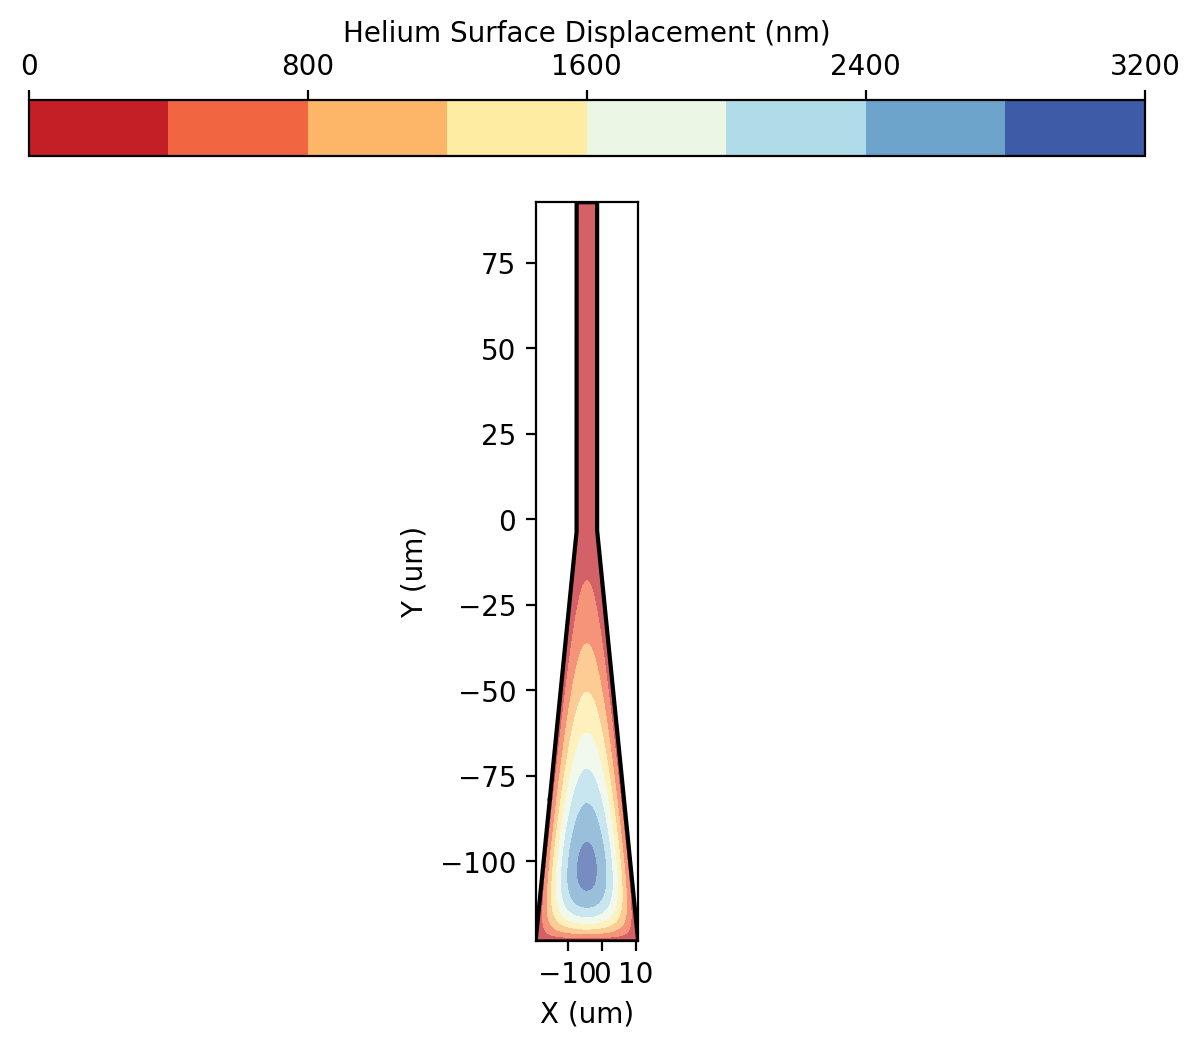

In [85]:
hsfreefem = HeliumSurfaceFreeFEM(fem_config=gmshmkr.export_physical())
res = hsfreefem.run_pyfreefem()

# plotting results of helium surface displacement for a bulk helium distance of 10 mm from the gnd surface
# note: the geometry units are in meters, so the bulk helium distance is set to 0.01m (10 mm)
hsfreefem.plot_results(res, bulk_helium_distance=0.01)


In [18]:
curvature_config = hsfreefem.get_code_config(bulk_helium_distances=[0, 0.001, 0.01, 0.02], surface_helium_level=d_He)
# curvature_config

### **Creating FreeFem configuration**

In [19]:
from zeroheliumkit.fem.freefemer import FFconfigurator, ExtractConfig, FreeFEM

In [20]:
He_level = d_He

var_eps = {
        'DIELECTRIC': 11.0,
        'METAL': 1.0,
        'HELIUM': 1.057,
        'VACUUM': 1.0,
}

ffc = FFconfigurator(config_file="dump/dot.yaml",
                     dielectric_constants=var_eps,
                     ff_polynomial=2,
                     extract_opt=[ExtractConfig("result1", 'phi', 'xy', (-10,10,201), (-10,10,201), d_He),
                                  ExtractConfig("result2", 'phi', 'xy', (-10,10,201), (-10,10,201), curvature_config),
                                  ExtractConfig("result3", 'Ez', 'yz', (-10,10,101), (-2,2,101), 0.0)
                                  ],
                     msh_refinements=None
                     )

In [21]:
pyff = FreeFEM(config_file="dump/dot.yaml")

In [22]:
await pyff.run(cores=4, print_log=False, remove=True)  # old code had remove_txt_blah so change to remove

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_mid.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_out.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_top.edp', layout=Layout(margin='4px 0'))

### **Parsing FEM results**

In [23]:
from zeroheliumkit.fem.fieldreader import FreeFemResultParser, FieldAnalyzer
from zeroheliumkit.src.settings import BLACK, WHITE

In [24]:
ffparser = FreeFemResultParser("dump/metadata.yaml")

                result1        result2                 result3
--------------  -------------  ----------------------  -------------
Quantity        phi            phi                     Ez
Plane           xy             xy                      yz
X Min           -10            -10                     -10
X Max           10             10                      10
X Num           201            201                     101
Y Min           -10            -10                     -2
Y Max           10             10                      2
Y Num           201            201                     101
Slices          1              4                       1
Slice Values    [1.6]          [0, 0.001, 0.01, 0.02]  [0.0]
Curved Surface  False          True                    False
Schema          (1, 201, 201)  (4, 201, 201)           (1, 101, 101)
Control Electrodes: ['mid', 'out', 'top']


In [25]:
ffparser.get_capacitance_matrix()

[[-321.827, 264.586, 67.7934],
 [258.553, -1858.05, 1726.25],
 [63.2758, 1593.46, -1794.04]]

In [15]:
fa = FieldAnalyzer(("dot", ffparser.load_data("dump/results", "result1")),
                   ("curved", ffparser.load_data("dump/results", "result2")))

NameError: name 'FieldAnalyzer' is not defined

In [14]:
fa.dot

NameError: name 'fa' is not defined

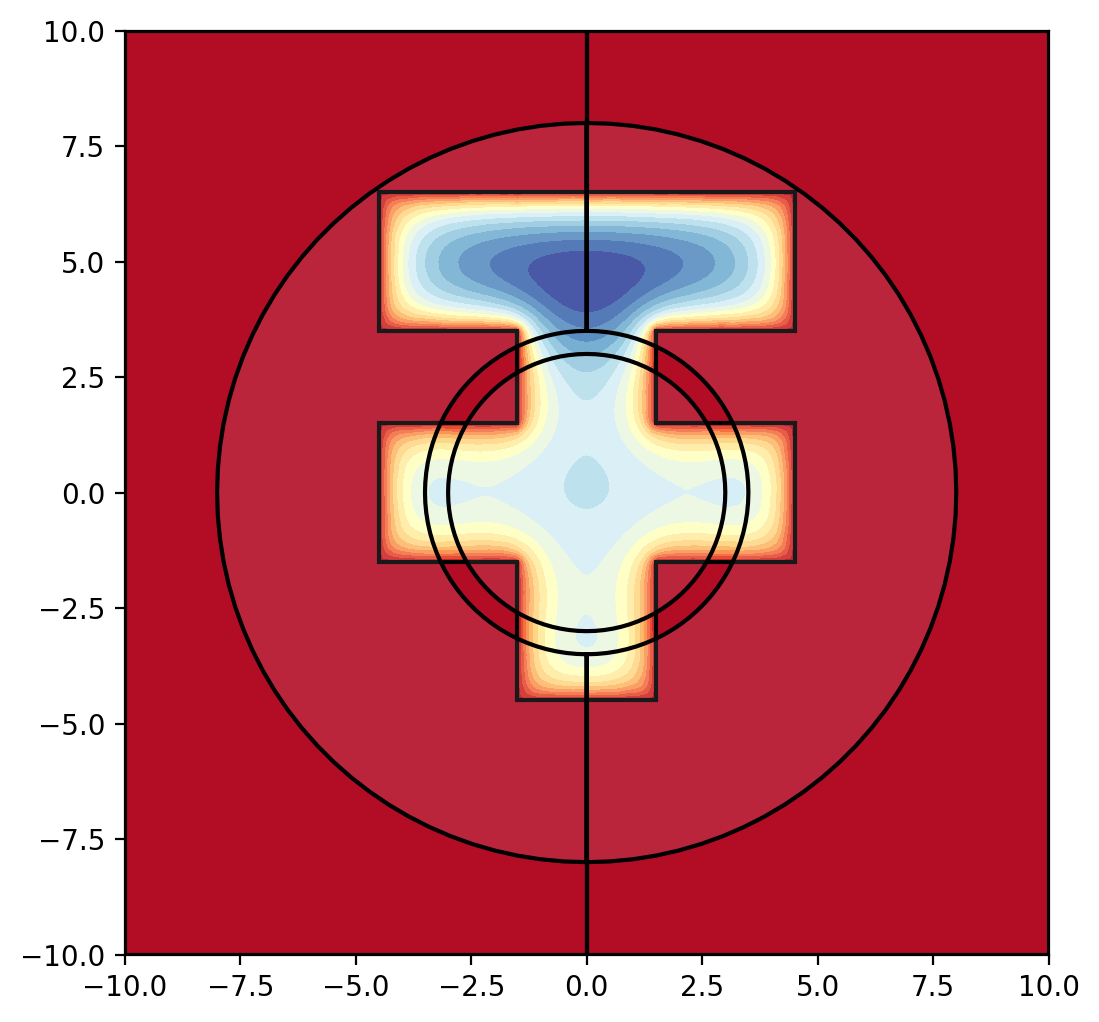

In [28]:
voltages = {
    "mid": 1,
    "out": 2,
    "top": -0.1
}

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

fa.plot_potential_2D(fa.dot, voltages, zlevel_key=1.6, ax=ax, zero_line=False, cmap='RdYlBu')
device.plot(ax=ax, layer=["gnd"], color=[BLACK], alpha=0)
device.plot(ax=ax, layer=["bottom"], color=[WHITE], alpha=0.1)

ax.set_aspect("equal")

plt.show()

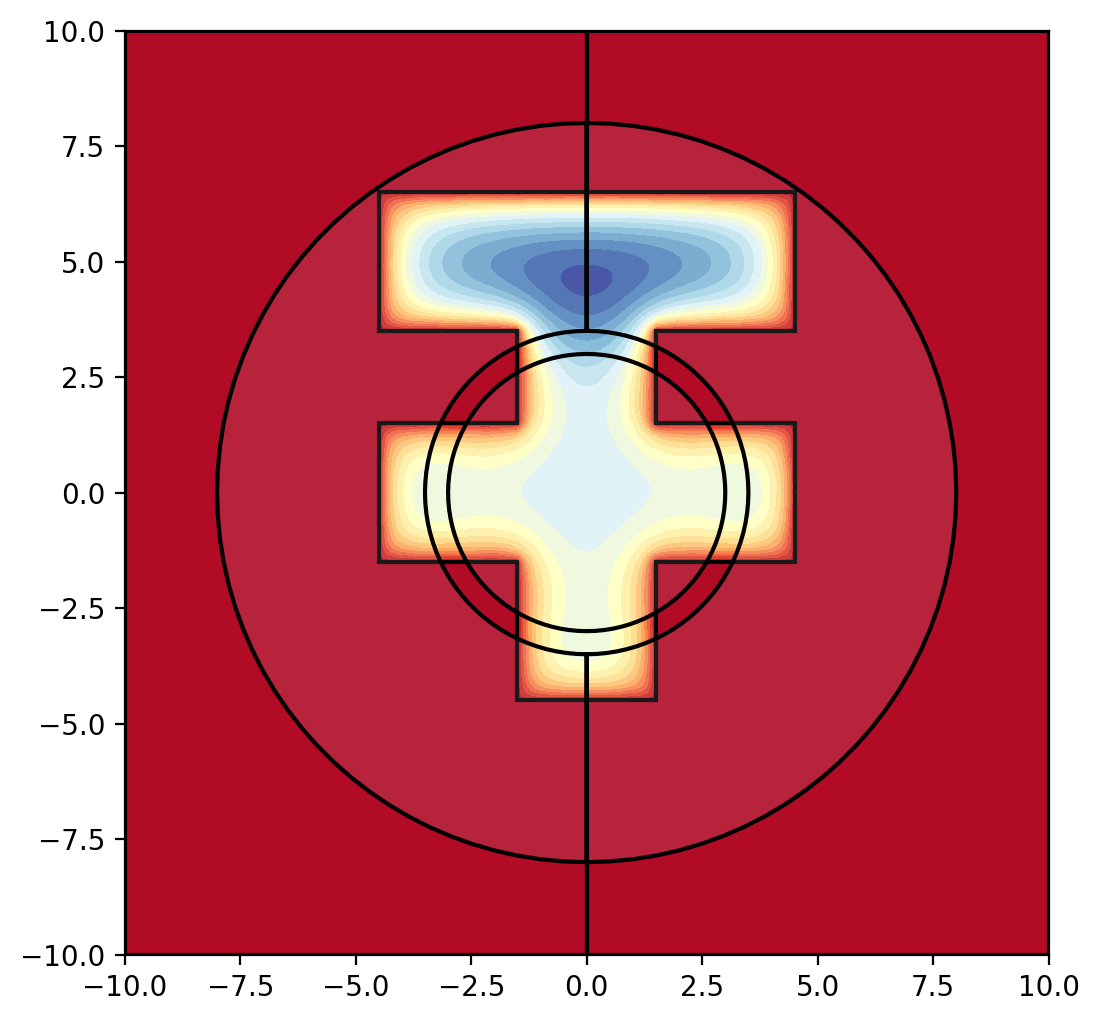

In [29]:
voltages = {
    "mid": 1,
    "out": 2,
    "top": -0.1
}

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

fa.plot_potential_2D(fa.curved, voltages, zlevel_key=0.02, ax=ax, zero_line=False, cmap='RdYlBu')
device.plot(ax=ax, layer=["gnd"], color=[BLACK], alpha=0)
device.plot(ax=ax, layer=["bottom"], color=[WHITE], alpha=0.1)

ax.set_aspect("equal")

plt.show()